In [7]:
"""  Code to bin our Sinistro light curves to improve SNR  """
import os
import pathlib
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
from lco_functions import file_load, file_len, create_lc, binned_lc

os.chdir(pathlib.Path.cwd())
def set_rcparams():
    """Set Matplotlib.rcparam data"""
    tab = Table.read('../../../rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
set_rcparams()

SAVEPATH = pathlib.Path('figures/sinistro/')
if not os.path.exists(SAVEPATH):
    SAVEPATH.mkdir(parents=True, exist_ok=True)

plt.style.use('dark_background')

COMMONPATH = '../../../data/lco_aumic/lcs_posttwirl/'
filepaths = sorted([os.path.join(COMMONPATH, specific) for \
                specific in os.listdir(COMMONPATH) if specific.endswith('.xls')])
# output order is B, U, V, gp, ip, rp

lens = [file_len(path) for path in [filepaths[3], filepaths[4], filepaths[5]]]
datas = []
for index, dataset in enumerate(zip(filepaths, [[None, None], [None, None],\
                                [None, None], [1, lens[0]-1],\
                                [8, lens[1]-7], [1, None]])):
    
    file, cleans = dataset
    datum = file_load(file)#| cleanrange=cleans)
    datas.append(datum)
BDATA, UDATA, VDATA, GDATA, IDATA, RDATA = datas

B_LC, BSNR = create_lc(*BDATA)
U_LC, USNR = create_lc(*UDATA)
V_LC, VSNR = create_lc(*VDATA)
G_LC, GSNR = create_lc(*GDATA)
I_LC, ISNR = create_lc(*IDATA)
R_LC, RSNR = create_lc(*RDATA)

U_LC = U_LC[U_LC['flux'] <16]

# Normalize the lcs
for lc in [B_LC, U_LC, V_LC, G_LC, R_LC, I_LC]:
    lc = lc.normalize()

# Now save the binned light curves as non-phase-folded and phase-folded versions
lcs = [G_LC, R_LC, I_LC, U_LC, B_LC, V_LC]
labs = ['gp', 'rp', 'ip', 'U', 'B', 'V']
binnedlcs, foldedlcs = [], []

for lc in lcs:
    binned, folded = binned_lc(lc.time.value, lc.flux, lc.flux_err)
    binnedlcs.append(binned)
    foldedlcs.append(folded)

for binned, fold, name in zip(binnedlcs, foldedlcs, labs):
    binned.to_csv(f'../../../data/lco_aumic/binned_sinistro/{name}.csv', overwrite=True)
    fold.to_csv(f'../../../data/lco_aumic/binned_sinistro/{name}_folded.csv', overwrite=True)

for lc in foldedlcs:
    lc /= np.median(lc[(lc['time'] > 0.5) & (lc['time'] < 1.0)]['flux'])

# Now let's plot them
G_FOLD, R_FOLD, I_FOLD, U_FOLD, B_FOLD, V_FOLD = foldedlcs
G_BIN, R_BIN, I_BIN, U_BIN, B_BIN, V_BIN = binnedlcs
colors = ['#0B6E4F', '#F9DB6D', '#764248', "#004BA8", "#6CCFF6", "#FFFFFF"]

# Sinistro phase-folded
fig, ax = plt.subplots(figsize=(16, 8))
for fold, col, lab in zip(foldedlcs, colors, labs):
    fold.normalize().errorbar(ax=ax, fmt='o', elinewidth=1, \
                              capsize=3, label=lab, c=col, rasterized=True)
ax.legend()
fig.savefig(os.path.join(SAVEPATH, 'sinistro_folded_binned_lcs.png'), dpi=300)
plt.clf()
plt.close()

# Sinistro not phase-folded
fig, ax = plt.subplots(figsize=(16, 8))
for binned, col, lab in zip(binnedlcs, colors, labs):
    binned.errorbar(ax=ax, fmt='o', elinewidth=1, capsize=3, label=lab, c=col, rasterized=True)
ax.legend()
ax.set_xlabel('Time [JD-2400000]')
fig.savefig(os.path.join(SAVEPATH, 'sinistro_binned_lcs.png'), dpi=300)
plt.clf()
plt.close()

# Both on the same figure
fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(24, 12), constrained_layout=True)
for fold, col, lab in zip(foldedlcs, colors, labs):
    fold.normalize().errorbar(ax=ax1, fmt='o', elinewidth=1, capsize=3,  c=col, rasterized=True)

for binned, col, lab in zip(binnedlcs, colors, labs):
    binned.normalize().errorbar(ax=ax2, fmt='o', elinewidth=1,\
                                 capsize=3, label=lab, c=col, rasterized=True)

ax1.set_xlabel('Time [MJD]')
ax2.set_xlabel('Time [JD-2400000]')
ax2.legend(fontsize=20)
fig.savefig(os.path.join(SAVEPATH, 'combined_sinistro_binned.png'), dpi=300)
plt.clf()
plt.close()


In [2]:
np.median(UDATA[2]) 

/Users/mschochet/anaconda3/envs/spot/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3858: RuntimeWarning: Mean of empty slice.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/Users/mschochet/anaconda3/envs/spot/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


np.float64(nan)

In [34]:
UDATA.mask = UDATA[2][UDATA[2] < 5 * np.median(UDATA[2])]

AttributeError: 'tuple' object has no attribute 'mask'

<ErrorbarContainer object of 3 artists>

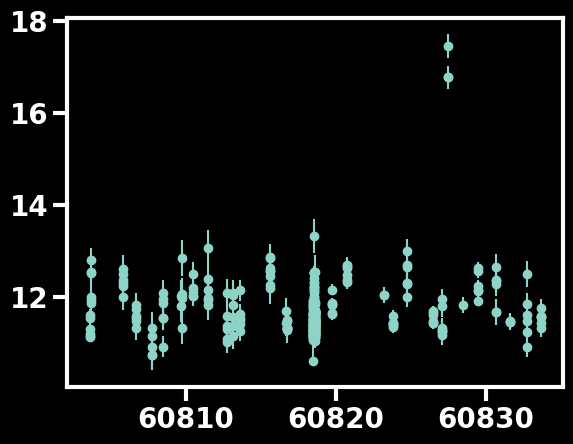

In [6]:
plt.errorbar(UDATA[0], UDATA[1], yerr=UDATA[2], fmt='o')
#plt.scatter(UDATA[0], UDATA[2])
#plt.xlim(60825, 60830)